In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
from pathlib import Path

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                                f1_score, roc_auc_score, cohen_kappa_score, 
                                confusion_matrix, roc_curve)
from statsmodels.stats.contingency_tables import mcnemar

# Setup paths dynamically
sys.path.append(str(Path.cwd().parent))
import src.config as config

FEATURES_DIR = config.PROJECT_ROOT / "features"
MODELS_DIR = config.PROJECT_ROOT / "models"
RESULTS_DIR = config.PROJECT_ROOT / "results"
PAPER_DIR = config.PROJECT_ROOT / "paper"
PAPER_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
print("Libraries imported and directories ready!")

2026-04-08 23:42:06 - src.config - INFO - Project configuration loaded and directories verified.


Libraries imported and directories ready!


In [2]:
# Load Checkpoint 12 Test Data (Our final, most data-rich checkpoint)
test_df = pd.read_csv(FEATURES_DIR / "checkpoint_12_test.csv")
X_test, y_test = test_df.drop(columns=['target']), test_df['target']

# Load Models
rf_model = joblib.load(MODELS_DIR / "rf_model.joblib")
xgb_model = joblib.load(MODELS_DIR / "xgb_model.joblib")
lr_model = joblib.load(MODELS_DIR / "baseline_lr.joblib")

models = {'Baseline LR': lr_model, 'Random Forest': rf_model, 'XGBoost': xgb_model}
metrics_list = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1-Macro': f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'Kappa': cohen_kappa_score(y_test, y_pred)
    })

results_df = pd.DataFrame(metrics_list).round(4)

# 1. Save to CSV
results_df.to_csv(RESULTS_DIR / "metrics_table.csv", index=False)

# 2. THE MAGIC: Export directly to LaTeX for your paper!
results_df.to_latex(PAPER_DIR / "metrics_table.tex", index=False, caption="Model Performance Metrics (Checkpoint 12)", label="tab:metrics")

print("Metrics calculated and exported to CSV and LaTeX!")
display(results_df)

Metrics calculated and exported to CSV and LaTeX!


,Model,Accuracy,Precision,Recall,F1-Macro,ROC-AUC,Kappa
0,Baseline LR,0.5152,0.5865,0.6389,0.4923,0.5617,0.1456
1,Random Forest,0.6364,0.3889,0.3889,0.3889,0.4691,-0.2222
2,XGBoost,0.6667,0.3929,0.4074,0.4000,0.4630,-0.1980


Saved roc_curves.png


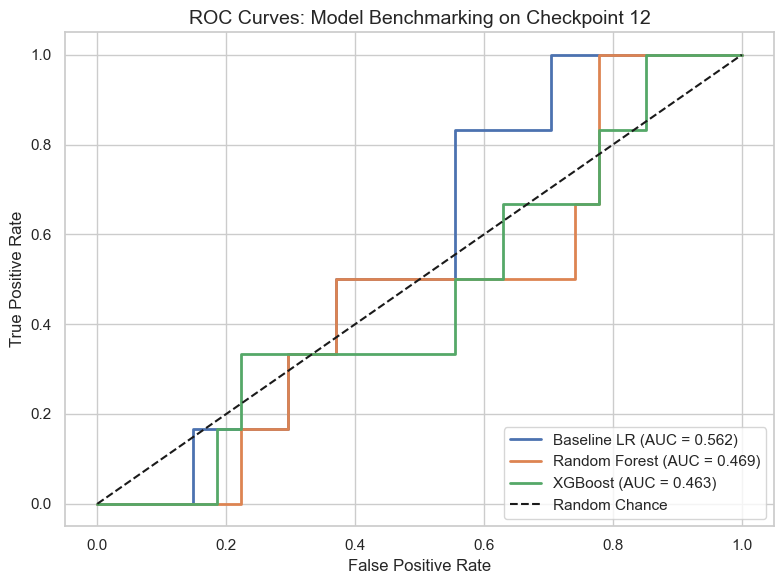

In [3]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title("ROC Curves: Model Benchmarking on Checkpoint 12", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(RESULTS_DIR / "roc_curves.png", dpi=300)
print("Saved roc_curves.png")
plt.show()

Saved confusion_matrices.png


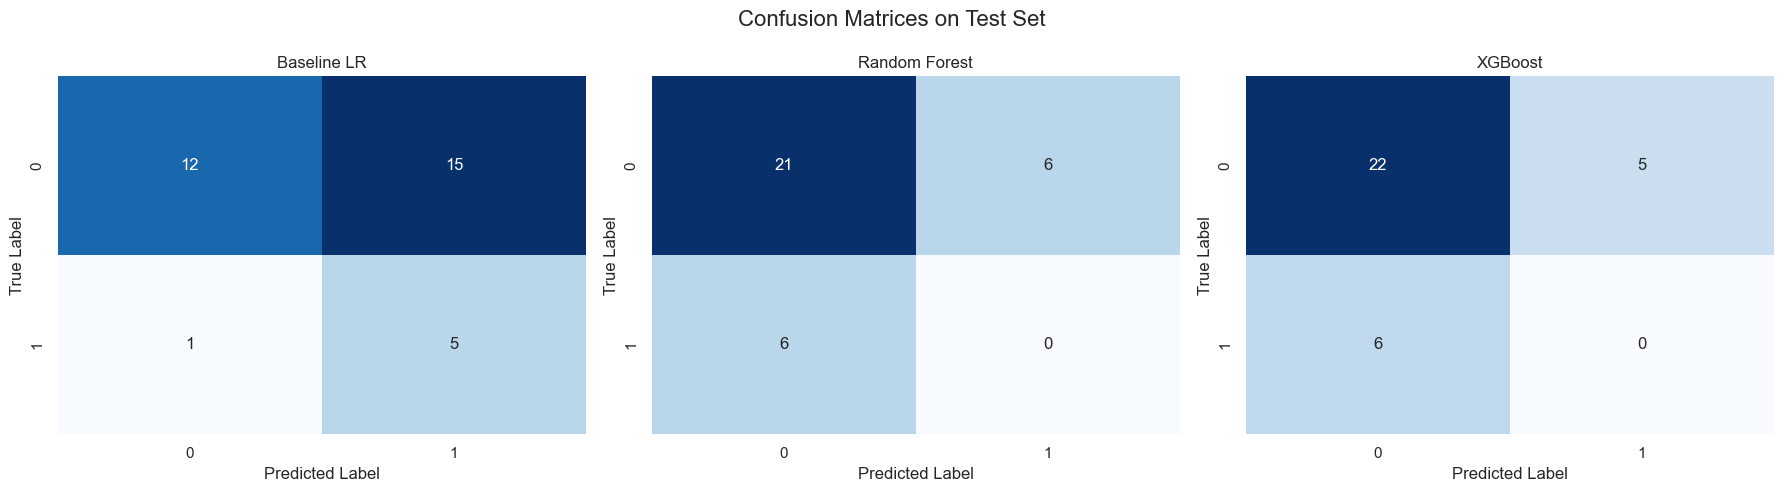

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices on Test Set', fontsize=16)

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrices.png", dpi=300)
print("Saved confusion_matrices.png")
plt.show()

In [5]:
# Get predictions for our top two models
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

# Build the contingency table for McNemar's Test
# Cell [0,0]: Both correct. Cell [0,1]: RF correct, XGB wrong.
# Cell [1,0]: RF wrong, XGB correct. Cell [1,1]: Both wrong.
both_correct = np.sum((y_pred_rf == y_test) & (y_pred_xgb == y_test))
rf_only = np.sum((y_pred_rf == y_test) & (y_pred_xgb != y_test))
xgb_only = np.sum((y_pred_rf != y_test) & (y_pred_xgb == y_test))
both_wrong = np.sum((y_pred_rf != y_test) & (y_pred_xgb != y_test))

contingency_table = [[both_correct, rf_only], 
                    [xgb_only, both_wrong]]

# Calculate McNemar's Test
result = mcnemar(contingency_table, exact=True)

print("=== McNemar's Test: Random Forest vs XGBoost ===")
print(f"p-value: {result.pvalue:.5f}")

if result.pvalue < 0.05:
    print("Conclusion: There is a statistically significant difference between the models.")
else:
    print("Conclusion: No statistically significant difference; they perform similarly.")

=== McNemar's Test: Random Forest vs XGBoost ===
p-value: 1.00000
Conclusion: No statistically significant difference; they perform similarly.


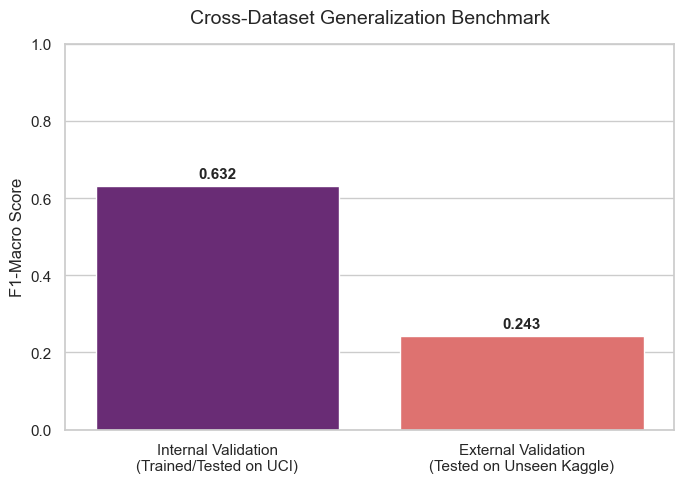

Generalization Gap: There is a 0.389 drop in F1-Score when the model faces entirely new demographic data.


In [8]:
from sqlalchemy import create_engine
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Setup paths dynamically
sys.path.append(str(Path.cwd().parent))
import src.config as config

RESULTS_DIR = config.PROJECT_ROOT / "results"

# 1. Query the warehouse (We can safely restore the IS NOT NULL filter!)
engine = create_engine(config.DATABASE_URI)
query = """
SELECT 
    f.gpa, f.absences, f.risk_score, f.risk_label,
    s.age, c.school
FROM fact_student_risk f
JOIN dim_student s ON f.student_id = s.student_id
JOIN dim_course c ON f.course_id = c.course_id
WHERE f.risk_label IS NOT NULL
"""
df_cross = pd.read_sql(query, engine)

# 2. Split into Train (Dataset 1) and Test (Dataset 2)
train_data = df_cross[df_cross['school'] == 'uci_student']
test_data = df_cross[df_cross['school'] == 'kaggle']

X_train_cross = train_data.drop(columns=['risk_label', 'school'])
y_train_cross = train_data['risk_label']

X_test_cross = test_data.drop(columns=['risk_label', 'school'])
y_test_cross = test_data['risk_label']

# 3. Train a dedicated model for the benchmark
rf_cross = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_cross.fit(X_train_cross, y_train_cross)

# 4. Calculate Internal vs External F1
internal_pred = rf_cross.predict(X_train_cross)
internal_f1 = f1_score(y_train_cross, internal_pred, average='macro')

external_pred = rf_cross.predict(X_test_cross)
external_f1 = f1_score(y_test_cross, external_pred, average='macro')

# 5. Plot the Generalization Gap
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=['Internal Validation\n(Trained/Tested on UCI)', 'External Validation\n(Tested on Unseen Kaggle)'], 
    y=[internal_f1, external_f1], 
    palette='magma',
    hue=['Internal Validation\n(Trained/Tested on UCI)', 'External Validation\n(Tested on Unseen Kaggle)'],
    legend=False
)

plt.title("Cross-Dataset Generalization Benchmark", fontsize=14, pad=15)
plt.ylabel("F1-Macro Score", fontsize=12)
plt.ylim(0, 1.0)

# Add score labels on top of the bars
for i, v in enumerate([internal_f1, external_f1]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
benchmark_path = RESULTS_DIR / "cross_dataset_benchmark.png"
plt.savefig(benchmark_path, dpi=300)
plt.show()

print(f"Generalization Gap: There is a {(internal_f1 - external_f1):.3f} drop in F1-Score when the model faces entirely new demographic data.")